# Drive Cycle Simulation

This notebook simulates battery response to the drive cycle.

## Overview
- **Drive Cycle**: Any (C-rate vs time)
- **Simulation**: Time-varying C-rate profile from drive cycle data
- **Output**: Voltage, current, temperature, and energy over time

In [1]:
# Import required libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet

## 1. Load Drive Cycle Data

In [2]:
# Load drive cycle (Power vs time)
drive_cycle = "Aero Quad Drone"
drive_cycle_path = Path(f"../drive_cycles/{drive_cycle}.csv")
drive_cycle_df = pd.read_csv(drive_cycle_path)

print(f"Drive cycle duration: {drive_cycle_df['time'].max()} seconds ({drive_cycle_df['time'].max()/60:.1f} min)")
print(f"Number of data points: {len(drive_cycle_df)}")
print(f"C-rate range: {drive_cycle_df['c_rate'].min():.3f} to {drive_cycle_df['c_rate'].max():.3f} C")

# Display first few rows
drive_cycle_df.head(10)

Drive cycle duration: 599 seconds (10.0 min)
Number of data points: 600
C-rate range: -5.122 to -1.477 C


,time,c_rate
0,0,-4.195740
1,1,-4.120930
2,2,-4.391733
3,3,-4.555423
4,4,-4.525072
5,5,-4.796417
6,6,-4.577884
7,7,-4.636169
8,8,-4.650775
9,9,-5.121651


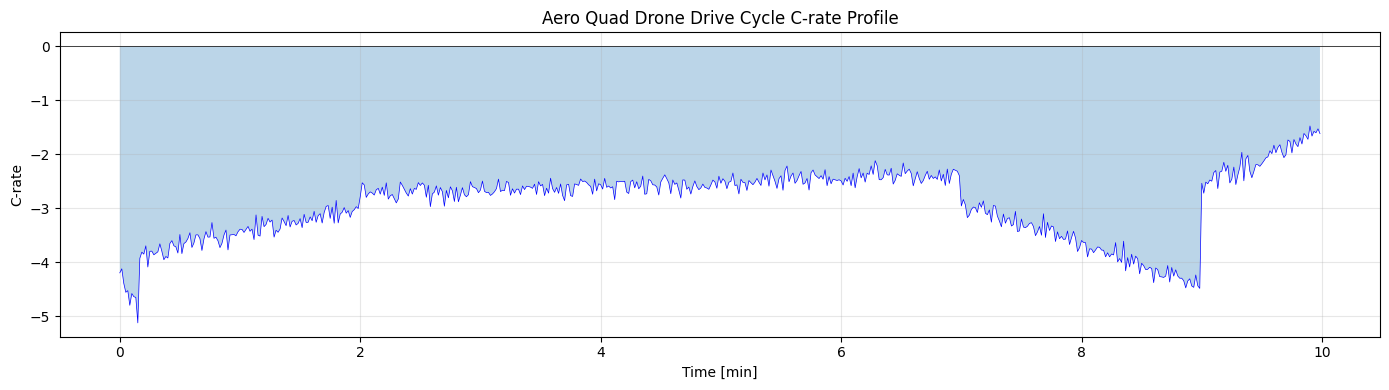

In [3]:
# Plot the drive cycle
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(drive_cycle_df['time']/60, drive_cycle_df['c_rate'], 'b-', linewidth=0.5)
ax.fill_between(drive_cycle_df['time']/60, drive_cycle_df['c_rate'], 0, alpha=0.3)
ax.set_xlabel('Time [min]')
ax.set_ylabel('C-rate')
ax.set_title(f'{drive_cycle} Drive Cycle C-rate Profile')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 2. Load Cell Parameters

In [4]:
# Load cell manifest
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    # Load material data for separator and electrolyte
    for component in ["separator", "electrolyte"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

    # Load material data for electrodes
    for component in ["negative_electrode", "positive_electrode"]:
        print(f"Loading material data for {component}") 
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        material_file_path = material_path / f"{material_name}.json"
        with open(material_file_path, "r") as mf:
            material_data = json.load(mf)
            cell_design_manifest["cell_design"][component]["material"] = material_data

nominal_capacity = cell_design_manifest['kpis']['nominal_capacity']['value']
nominal_energy = cell_design_manifest["kpis"]["nominal_energy"]["value"] 
cell_design = cell_design_manifest["cell_design"]
upper_voltage_cutoff = cell_design["upper_voltage_cutoff"]["value"]
lower_voltage_cutoff = cell_design["lower_voltage_cutoff"]["value"]
cell_design["nominal_capacity"] = {"value": nominal_capacity, "unit": "Ah"}
cell_design["nominal_energy"] = {"value": nominal_energy, "unit": "Wh"}
cell_design["cell_volume"] = {
    "value": cell_design_manifest['kpis']['cell_volume']['value'],
    "unit": "cm3"
}

print(f"\nCell: {manifest_path.stem}")
print(f"Nominal capacity: {nominal_capacity:.1f} Ah")
print(f"Nominal energy: {nominal_energy:.1f} Wh")
print(f"Voltage range: {lower_voltage_cutoff:.2f} - {upper_voltage_cutoff:.2f} V")

Loading material data for separator
Loading material data for electrolyte
Loading material data for negative_electrode
Loading material data for positive_electrode

Cell: Tesla_Model3_Prismatic_160Ah_manifest
Nominal capacity: 161.1 Ah
Nominal energy: 515.5 Wh
Voltage range: 2.50 - 3.65 V


## 3. Run Simulation with Drive Cycle

In [5]:
# Prepare drive cycle data
# C-rate values in the CSV are negative for discharge
# Flip sign so positive = discharge for PyBaMM
time_s = drive_cycle_df['time'].values
c_rate = -drive_cycle_df['c_rate'].values  # Flip sign

print(f"C-rate range for simulation: {c_rate.min():.3f} to {c_rate.max():.3f} C")
print(f"Average C-rate: {c_rate.mean():.3f} C")

C-rate range for simulation: 1.477 to 5.122 C
Average C-rate: 2.922 C


In [6]:
# Configure simulation with drive cycle
sim_config = {
    "ambient_temperature": 298.15,  # 25C
    "initial_temperature": 298.15,  # 25C
    "initial_soc": 0.8,  # Start at 80% SOC
    "upper_voltage_cutoff": upper_voltage_cutoff,
    "lower_voltage_cutoff": lower_voltage_cutoff,
    "contact_resistance": 0.0001,
    "total_heat_transfer_coefficient": 10,
    "cooling_surface_area": 0.01,
    "period": "1 second",
    # Drive cycle data (C-rate)
    "drive_cycle": {
        "time_s": time_s,
        "c_rate": c_rate,
        "label": drive_cycle,
    },
}

# Run simulation
results = run_spmet(cell_design=cell_design, simulation_config=sim_config)


Building model parameters from manifest...

CAPACITY CALIBRATION
Target capacity: 161.10 Ah
Convergence tolerance: 0.010%
--------------------------------------------------------------------------------
Iteration  1: Capacity =  59.74 Ah, Error = 62.917%
Iteration  2: Capacity = 163.53 Ah, Error =  1.510%
Iteration  3: Capacity = 161.07 Ah, Error =  0.019%
Iteration  4: Capacity = 161.10 Ah, Error =  0.000%
--------------------------------------------------------------------------------
Converged after 4 iterations!

RUNNING DRIVE CYCLE
  Type: C-rate
  C-rate range: 1.477 to 5.122 C
  Label: Aero Quad Drone
  Duration: 599.0 s (10.0 min)
  Data points: 600
  Running simulation (initial SOC: 80%)...
  Completed: 600 data points


## 4. Extract Results

In [7]:
# Extract simulation results
result = results[0]

if result['success']:
    sim_time = result['time_s']
    sim_voltage = result['voltage_V']
    sim_current = result['current_A']
    sim_power = result['power_W']
    sim_temp = result['temperature_K'] - 273.15  # Convert to Celsius
    sim_capacity = result['capacity_Ah']
    sim_energy = result['energy_Wh']

    print("\nSimulation Summary:")
    print(f"  Duration: {sim_time[-1]:.1f} s ({sim_time[-1]/60:.1f} min)")
    print(f"  Voltage range: {sim_voltage.min():.3f} - {sim_voltage.max():.3f} V")
    print(f"  Current range: {sim_current.min():.1f} - {sim_current.max():.1f} A")
    print(f"  Power range: {sim_power.min():.1f} - {sim_power.max():.1f} W")
    print(f"  Temperature range: {sim_temp.min():.2f} - {sim_temp.max():.2f} C")
    print(f"  Capacity discharged: {sim_capacity[-1] - sim_capacity[0]:.2f} Ah")
    print(f"  Energy discharged: {sim_energy[-1] - sim_energy[0]:.2f} Wh")
else:
    print(f"Simulation failed: {result.get('error', 'Unknown error')}")


Simulation Summary:
  Duration: 599.0 s (10.0 min)
  Voltage range: 3.050 - 3.420 V
  Current range: 237.9 - 825.1 A
  Power range: 758.5 - 2760.5 W
  Temperature range: 25.00 - 47.05 C
  Capacity discharged: 78.34 Ah
  Energy discharged: 255.61 Wh


## 5. Visualize Results

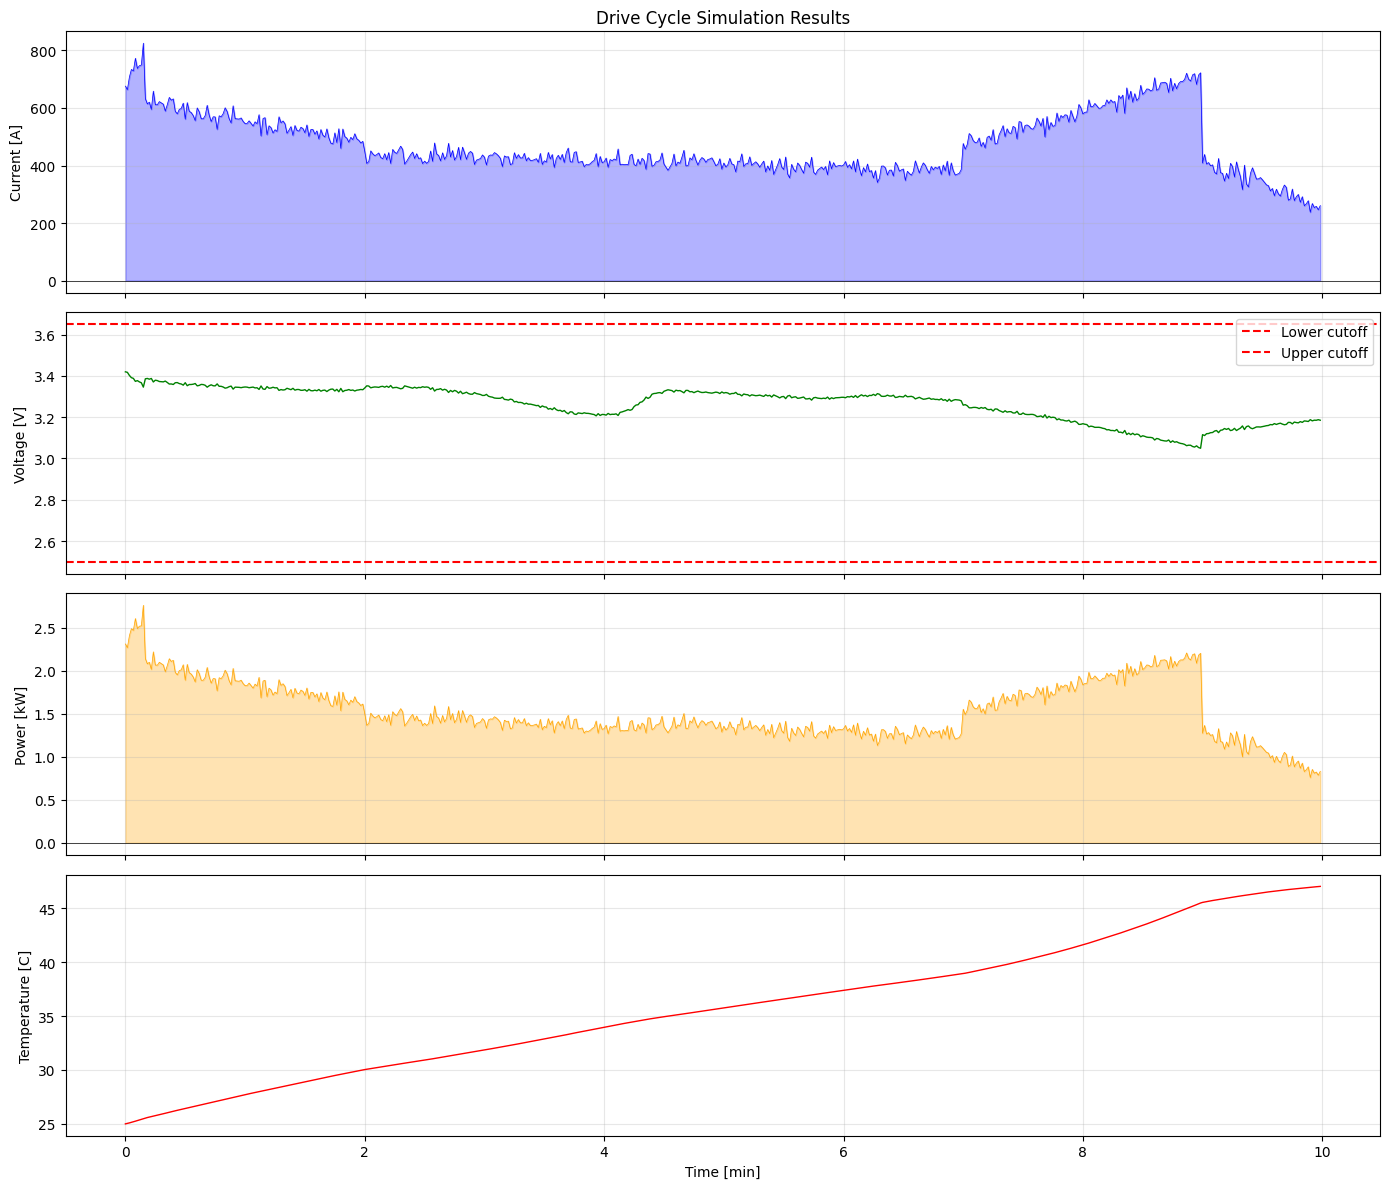

In [ ]:
if result['success']:
    # Plot results
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

    # Current profile
    ax1 = axes[0]
    ax1.plot(sim_time/60, sim_current, 'b-', linewidth=0.5)
    ax1.fill_between(sim_time/60, sim_current, 0, alpha=0.3, color='blue')
    ax1.set_ylabel('Current [A]')
    ax1.set_title(f'{drive_cycle} Drive Cycle Simulation Results')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

    # Voltage response
    ax2 = axes[1]
    ax2.plot(sim_time/60, sim_voltage, 'g-', linewidth=1)
    ax2.axhline(y=lower_voltage_cutoff, color='r', linestyle='--', label='Lower cutoff')
    ax2.axhline(y=upper_voltage_cutoff, color='r', linestyle='--', label='Upper cutoff')
    ax2.set_ylabel('Voltage [V]')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # Power
    ax3 = axes[2]
    ax3.plot(sim_time/60, sim_power/1000, 'orange', linewidth=0.5)
    ax3.fill_between(sim_time/60, sim_power/1000, 0, alpha=0.3, color='orange')
    ax3.set_ylabel('Power [kW]')
    ax3.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax3.grid(True, alpha=0.3)

    # Temperature response
    ax4 = axes[3]
    ax4.plot(sim_time/60, sim_temp, 'r-', linewidth=1)
    ax4.set_xlabel('Time [min]')
    ax4.set_ylabel('Temperature [C]')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

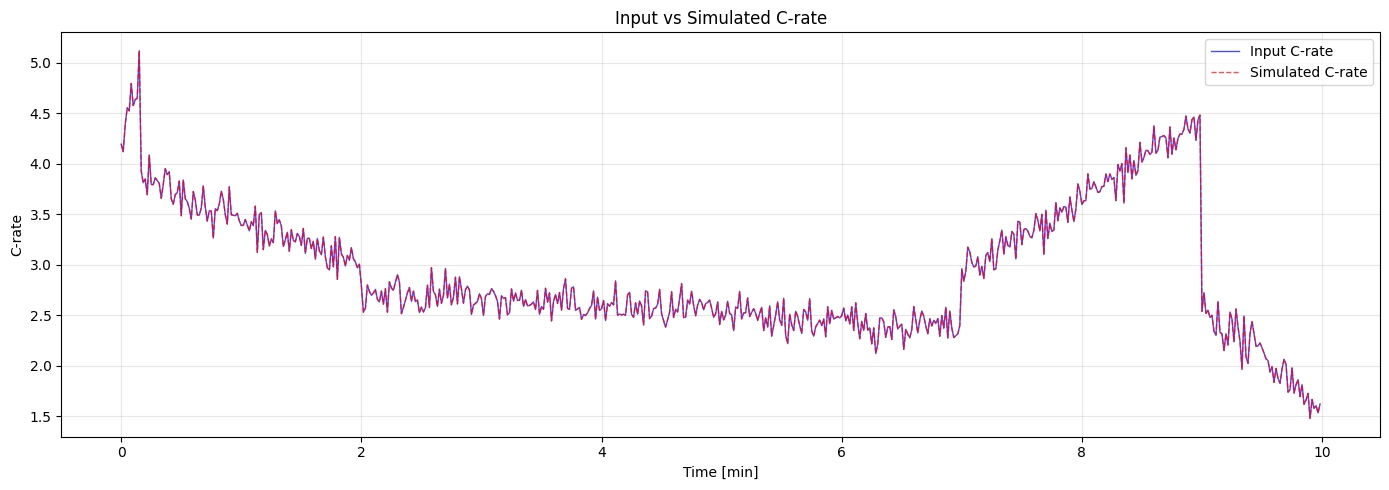

In [9]:
if result['success']:
    # Compare input C-rate with simulated current (normalized)
    fig, ax = plt.subplots(figsize=(14, 5))

    # Normalize simulated current to C-rate
    sim_c_rate = sim_current / nominal_capacity

    ax.plot(time_s/60, c_rate, 'b-', linewidth=1, alpha=0.7, label='Input C-rate')
    ax.plot(sim_time/60, sim_c_rate, 'r--', linewidth=1, alpha=0.7, label='Simulated C-rate')
    ax.set_xlabel('Time [min]')
    ax.set_ylabel('C-rate')
    ax.set_title('Input vs Simulated C-rate')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Energy Analysis

In [10]:
if result['success']:
    # Calculate energy metrics
    dt = np.diff(sim_time)
    power_mid = (sim_power[:-1] + sim_power[1:]) / 2

    # Separate discharge and regen energy
    discharge_mask = power_mid > 0
    regen_mask = power_mid < 0

    energy_discharge_Wh = np.sum(power_mid[discharge_mask] * dt[discharge_mask]) / 3600
    energy_regen_Wh = -np.sum(power_mid[regen_mask] * dt[regen_mask]) / 3600
    energy_net_Wh = energy_discharge_Wh - energy_regen_Wh

    # SOC change
    capacity_change = sim_capacity[-1] - sim_capacity[0]
    soc_change = capacity_change / nominal_capacity * 100

    print("Energy Analysis:")
    print(f"  Energy discharged: {energy_discharge_Wh:.2f} Wh")
    print(f"  Energy regenerated: {energy_regen_Wh:.2f} Wh")
    print(f"  Net energy consumed: {energy_net_Wh:.2f} Wh")
    if energy_discharge_Wh > 0:
        print(f"  Regeneration ratio: {energy_regen_Wh/energy_discharge_Wh*100:.1f}%")
    print(f"\n  Capacity used: {capacity_change:.2f} Ah")
    print(f"  SOC change: {soc_change:.1f}%")
    
    # Store for range analysis
    energy_per_cycle_Wh = energy_net_Wh
    capacity_per_cycle_Ah = capacity_change
    cycle_duration_s = sim_time[-1] - sim_time[0]

Energy Analysis:
  Energy discharged: 255.60 Wh
  Energy regenerated: -0.00 Wh
  Net energy consumed: 255.60 Wh
  Regeneration ratio: -0.0%

  Capacity used: 78.34 Ah
  SOC change: 48.6%


## 7. Range Analysis

Estimate how far a vehicle/drone can travel on a single charge based on the drive cycle simulation.

In [11]:
if result['success']:
    # ============================================================================
    # DRIVE CYCLE PARAMETERS
    # ============================================================================
    # Known drive cycle distances (standard test cycles)
    # Set the appropriate value for your drive cycle
    
    drive_cycle_distances = {
        # Automotive cycles
        "Auto WLTP": 23.266,        # km - WLTP Class 3 full cycle
        "Auto US06": 12.8,          # km - US06 aggressive driving cycle
        "Track Nurburgring": 20.8,  # km - Nurburgring Nordschleife
        # Aerial cycles (estimate based on typical speeds)
        "Aero Quad Drone": None,    # Use flight time instead
        "Aero UAV": None,           # Use flight time instead  
        "Aero eVTOL": None,         # Use flight time instead
    }
    
    # Detect cycle type from path
    cycle_name = drive_cycle_path.stem
    cycle_distance_km = drive_cycle_distances.get(cycle_name)
    
    # For aerial vehicles, use average speed assumption if no distance
    # Typical speeds: Quad drone ~40 km/h, UAV ~80 km/h, eVTOL ~150 km/h
    aerial_speeds = {
        "Aero Quad Drone": 40,   # km/h
        "Aero UAV": 80,          # km/h
        "Aero eVTOL": 150,       # km/h
    }
    
    if cycle_distance_km is None and cycle_name in aerial_speeds:
        avg_speed_kmh = aerial_speeds[cycle_name]
        cycle_distance_km = avg_speed_kmh * (cycle_duration_s / 3600)
        is_aerial = True
    else:
        is_aerial = False
        avg_speed_kmh = (cycle_distance_km / cycle_duration_s) * 3600 if cycle_distance_km else None
    
    print("=" * 60)
    print("RANGE ANALYSIS")
    print("=" * 60)
    print(f"\nDrive Cycle: {cycle_name}")
    print(f"Cycle duration: {cycle_duration_s:.0f} s ({cycle_duration_s/60:.1f} min)")
    
    if cycle_distance_km:
        print(f"Cycle distance: {cycle_distance_km:.2f} km")
        print(f"Average speed: {avg_speed_kmh:.1f} km/h")
    
    # ============================================================================
    # USABLE BATTERY CAPACITY
    # ============================================================================
    # Define usable SOC window (typical: 10% to 90% for longevity)
    min_soc = 0.10  # Don't discharge below 10%
    max_soc = 0.90  # Don't charge above 90% (or use 1.0 for full)
    initial_soc_sim = sim_config["initial_soc"]
    
    usable_capacity_Ah = nominal_capacity * (max_soc - min_soc)
    usable_energy_Wh = nominal_energy * (max_soc - min_soc)
    
    # From simulation starting SOC to min SOC
    available_capacity_Ah = nominal_capacity * (initial_soc_sim - min_soc)
    available_energy_Wh = nominal_energy * (initial_soc_sim - min_soc)
    
    print(f"\n--- Battery Parameters ---")
    print(f"Nominal capacity: {nominal_capacity:.1f} Ah ({nominal_energy:.1f} Wh)")
    print(f"Usable SOC window: {min_soc*100:.0f}% - {max_soc*100:.0f}%")
    print(f"Usable capacity: {usable_capacity_Ah:.1f} Ah ({usable_energy_Wh:.1f} Wh)")
    print(f"Starting SOC: {initial_soc_sim*100:.0f}%")
    print(f"Available from start: {available_capacity_Ah:.1f} Ah ({available_energy_Wh:.1f} Wh)")
    
    # ============================================================================
    # RANGE CALCULATION
    # ============================================================================
    print(f"\n--- Per-Cycle Consumption ---")
    print(f"Energy per cycle: {energy_per_cycle_Wh:.2f} Wh")
    print(f"Capacity per cycle: {capacity_per_cycle_Ah:.2f} Ah")
    
    if cycle_distance_km and cycle_distance_km > 0:
        energy_per_km = energy_per_cycle_Wh / cycle_distance_km
        capacity_per_km = capacity_per_cycle_Ah / cycle_distance_km
        print(f"Energy consumption: {energy_per_km:.2f} Wh/km ({energy_per_km*1.609:.2f} Wh/mile)")
        print(f"Capacity consumption: {capacity_per_km*1000:.2f} mAh/km")
    
    # Number of complete cycles possible
    cycles_possible = available_capacity_Ah / capacity_per_cycle_Ah
    
    print(f"\n--- Range Estimate ---")
    print(f"Cycles possible (from {initial_soc_sim*100:.0f}% to {min_soc*100:.0f}%): {cycles_possible:.2f}")
    
    if cycle_distance_km and cycle_distance_km > 0:
        total_range_km = cycles_possible * cycle_distance_km
        total_range_miles = total_range_km * 0.621371
        print(f"Estimated range: {total_range_km:.1f} km ({total_range_miles:.1f} miles)")
    
    # Flight/drive time
    total_time_s = cycles_possible * cycle_duration_s
    total_time_min = total_time_s / 60
    total_time_hr = total_time_s / 3600
    
    if is_aerial:
        print(f"Estimated flight time: {total_time_min:.1f} min ({total_time_hr:.2f} hours)")
    else:
        print(f"Estimated drive time: {total_time_min:.1f} min ({total_time_hr:.2f} hours)")
    
    # Full charge estimate (from max_soc to min_soc)
    full_charge_capacity = nominal_capacity * (max_soc - min_soc)
    full_cycles = full_charge_capacity / capacity_per_cycle_Ah
    
    print(f"\n--- Full Charge Range ({max_soc*100:.0f}% to {min_soc*100:.0f}%) ---")
    if cycle_distance_km and cycle_distance_km > 0:
        full_range_km = full_cycles * cycle_distance_km
        full_range_miles = full_range_km * 0.621371
        print(f"Range: {full_range_km:.1f} km ({full_range_miles:.1f} miles)")
    
    full_time_min = full_cycles * cycle_duration_s / 60
    if is_aerial:
        print(f"Flight time: {full_time_min:.1f} min ({full_time_min/60:.2f} hours)")
    else:
        print(f"Drive time: {full_time_min:.1f} min ({full_time_min/60:.2f} hours)")

RANGE ANALYSIS

Drive Cycle: Aero Quad Drone
Cycle duration: 599 s (10.0 min)
Cycle distance: 6.66 km
Average speed: 40.0 km/h

--- Battery Parameters ---
Nominal capacity: 161.1 Ah (515.5 Wh)
Usable SOC window: 10% - 90%
Usable capacity: 128.9 Ah (412.4 Wh)
Starting SOC: 80%
Available from start: 112.8 Ah (360.9 Wh)

--- Per-Cycle Consumption ---
Energy per cycle: 255.60 Wh
Capacity per cycle: 78.34 Ah
Energy consumption: 38.40 Wh/km (61.79 Wh/mile)
Capacity consumption: 11769.94 mAh/km

--- Range Estimate ---
Cycles possible (from 80% to 10%): 1.44
Estimated range: 9.6 km (6.0 miles)
Estimated flight time: 14.4 min (0.24 hours)

--- Full Charge Range (90% to 10%) ---
Range: 10.9 km (6.8 miles)
Flight time: 16.4 min (0.27 hours)


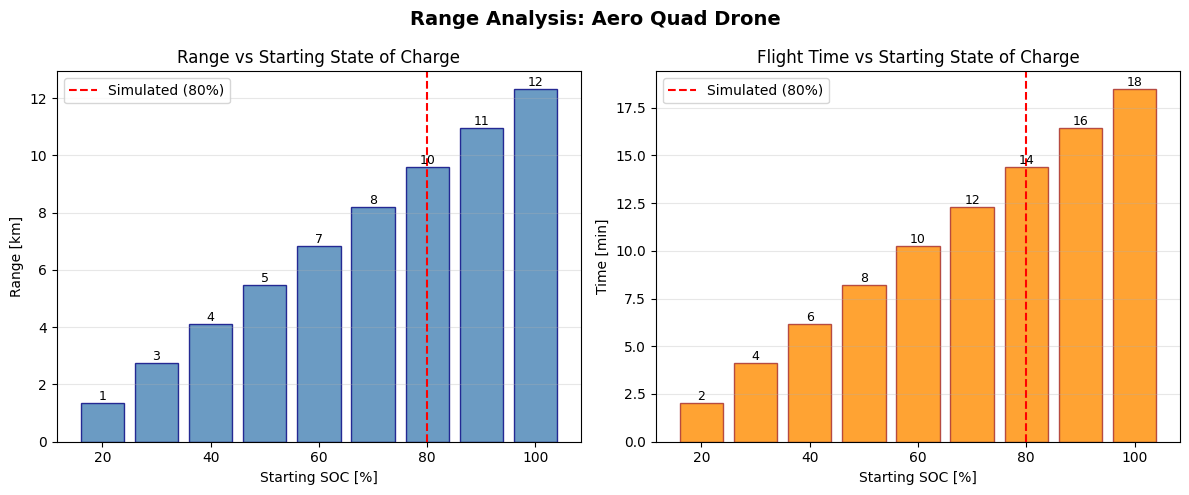

In [12]:
if result['success']:
    # Visualize range at different starting SOCs
    soc_levels = np.arange(0.2, 1.01, 0.1)  # 20% to 100%
    ranges_km = []
    times_min = []
    
    for soc in soc_levels:
        avail_cap = nominal_capacity * (soc - min_soc)
        if avail_cap > 0:
            n_cycles = avail_cap / capacity_per_cycle_Ah
            if cycle_distance_km:
                ranges_km.append(n_cycles * cycle_distance_km)
            times_min.append(n_cycles * cycle_duration_s / 60)
        else:
            ranges_km.append(0) if cycle_distance_km else None
            times_min.append(0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Range vs SOC
    if cycle_distance_km:
        ax1 = axes[0]
        ax1.bar(soc_levels * 100, ranges_km, width=8, color='steelblue', edgecolor='navy', alpha=0.8)
        ax1.set_xlabel('Starting SOC [%]')
        ax1.set_ylabel('Range [km]')
        ax1.set_title('Range vs Starting State of Charge')
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.axvline(x=initial_soc_sim * 100, color='red', linestyle='--', label=f'Simulated ({initial_soc_sim*100:.0f}%)')
        ax1.legend()
        for i, (soc, r) in enumerate(zip(soc_levels, ranges_km)):
            ax1.annotate(f'{r:.0f}', (soc*100, r), ha='center', va='bottom', fontsize=9)
    
    # Time vs SOC
    ax2 = axes[1]
    ax2.bar(soc_levels * 100, times_min, width=8, color='darkorange', edgecolor='brown', alpha=0.8)
    ax2.set_xlabel('Starting SOC [%]')
    ax2.set_ylabel('Time [min]')
    title = 'Flight Time' if is_aerial else 'Drive Time'
    ax2.set_title(f'{title} vs Starting State of Charge')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.axvline(x=initial_soc_sim * 100, color='red', linestyle='--', label=f'Simulated ({initial_soc_sim*100:.0f}%)')
    ax2.legend()
    for i, (soc, t) in enumerate(zip(soc_levels, times_min)):
        ax2.annotate(f'{t:.0f}', (soc*100, t), ha='center', va='bottom', fontsize=9)
    
    plt.suptitle(f'Range Analysis: {cycle_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()